# **Adiabatic Quantum Annealing**
---
<img src="Imperial_logo.png" align = "left" width=200>
 <br>
 
- Copyright (c) Jack Jacquier, 2025. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9

In [1]:
import numpy as np
import sympy as sym
from IPython.display import display
from sympy.physics.quantum import TensorProduct
from sympy import symbols
from matplotlib import pyplot as plt

$$\DeclarePairedDelimiter\bra{\langle}{\rvert}$$
$$\DeclarePairedDelimiter\ket{\lvert}{\rangle}$$
$$\newcommand{\Hh}{\mathcal{H}}$$
$$\newcommand{\RR}{\mathbb{R}}$$
$$\newcommand{\CC}{\mathbb{C}}$$
$$\newcommand{\EE}{\mathbb{E}}$$
$$\newcommand{\D}{\mathrm{d}}$$
$$\newcommand{\E}{\mathrm{e}}$$
$$\newcommand{\I}{\mathrm{i}}$$
$$\newcommand{\Uu}{\mathcal{U}}$$
$$\newcommand{\Ig}{\mathtt{I}}$$
$$\newcommand{\Ug}{\mathtt{U}}$$
$$\newcommand{\Xg}{\mathtt{X}}$$
$$\newcommand{\Zg}{\mathtt{Z}}$$
$$\newcommand{\Mm}{\mathcal{M}}$$

# An optimisation problem

$$
\textbf{Problem: } \text{Given }f:\{0,1\}^n \to \RR, \qquad \min_{z\in \{0,1\}^n} f(z).
$$

- Hamiltonian formulation: $\displaystyle \Hh := \sum_{z\in\{0,1\}^n}f(z)\ket{z}\bra{z}$.

- If $(\ket{z_i})$ are eigenvectors of $\Hh$, then
\begin{equation*}
\begin{array}{rll}
\Hh_{F}\ket{z_i} & = \displaystyle \left(\sum_{z\in\{0,1\}^n}f(z)\ket{z}\bra{z}\right)\ket{z_i}\\
 & = \displaystyle \left(\sum_{z\in\{0,1\}^n \setminus\{z_i\}}f(z)\ket{z}\bra{z}\right)\ket{z_i}
& +  \displaystyle \Big(f(z_i)\ket{z_i}\bra{z_i}\Big)\ket{z_i}\\
 & = 0 & + f(z_i)\ket{z_i}\braket{z_i|z_i}\\
 &  = f(z_i)\ket{z_i},
\end{array}
\end{equation*}
so that $(f(z_i))$ are eigenvalues of~$\Hh$.

- Solving the optimisation problem above amounts to finding the smallest eigenvalues (minimum energy) of $\Hh$.

- Problem: it is often difficult to find them.

### Constant Hamiltonian simulation

Schr\"odinger equation:
$$
    \I \frac{\D \ket{\psi(t)}}{\D t}
    = \Hh\ket{\psi(t)}, \quad t\in[0,\tau]
    \qquad\text{(Schr\"{o}dinger equation)}.
$$
is solved at time $t\geq 0$ as
$$
\ket{\psi(t)} =  \E^{-\I\Hh t}
\ket{\psi(0)}.
$$
If $\Hh\ket{\psi_{0}} = \lambda_{0}\ket{\psi_{0}}$, then 
$$
\ket{\psi(t)} =  \E^{-\I\Hh t}\ket{\psi_{0}}
 = \E^{-\I\lambda_{0} t}\ket{\psi_{0}},
$$
i.e. no transition over time between different eigenstates!!

## Time-dependent Hamiltonian simulation $\Hh(\cdot)$

Schr\"odinger equation over $[0,\tau]$;
time change $t(\cdot)$ with $t(0)=1$ and $t(1)=\tau$:
$$
\I \frac{\D \ket{\psi(s)}}{\D s} = t'(s)\Hh(s) \ket{\psi(s)},
    \qquad\text{on }[0,1].
$$
Consider 
$$
\Hh(s) = r(s) \Hh_0 + (1-r(s)) \Hh_F,
$$
for two Hamiltonians $\Hh_0$ and $\Hh_F$, where $r(\cdot)$ is a continuous adiabatic evolution path decreasing from $r(0)=1$ 
to $r(1)=0$.

Let $\ket{\psi(\cdot)}$ be the solution to the Schr\"odinger equation, so that 
$$
\ket{\psi(s)} = \Uu(s) \ket{\psi(0)},
\qquad\text{for some unitary operator~$\Uu$}.
$$

Consider the equation above with
$t(s) = s \tau$, hence
$$
\I \frac{\D \ket{\psi(s)}}{\D s}
    = \tau \Hh(s)\ket{\psi(s)},
    \qquad\text{on }[0,1].
$$


## Quantum Adiabatic Theorem

Let $\ket{\phi(s)}$ be the ground state of $\Hh(s)$ and the adiabatic schedule $r(s) = 1-s$:
$$
\Hh(s) = (1-s) \Hh_0 + s \Hh_F.
$$

**Theorem**
Assume that $\Hh_0$ and $\Hh_F$ do not commute and that there is no spectral gap.
If there exists $\delta>0$ such that
$$
\tau \geq \frac{2}{\delta}
\left\{
C_0\frac{\|\Hh_F - \Hh_0\|}{\overline{\Delta}^2}
  + C_1
\frac{\|\Hh_F - \Hh_0\|^2}
    {\overline{\Delta}^3}
    \right\},
$$
with $\overline{\Delta}:=\min_{s\in [0,1]}\Delta_s$,
then, starting the system in the state $\ket{\psi(0)} = \ket{\phi(0)}$, 
the Schr\"odinger evolution yields at time $1$ a state $\ket{\psi(1)}$ satisfying
$$
\left\|\ket{\phi(1)} - \ket{\psi(1)}\right\|\leq \delta.
$$


# Example: the 1-bit Disagree problem

## The non-commuting case

The 1-bit Disagree problem reads
\begin{equation*}
f(z) := \left\{
\begin{array}{ll}
1, & \text{if } z=1,\\
0, & \text{if } z=0.
\end{array}
\right.
\end{equation*}
$$
\Hh_F := \frac{1+\sigma^z}{2}
= \frac{1}{2}
\left(\begin{pmatrix}
1 & 0\\
0 & 1
\end{pmatrix} +
\begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix}
\right)
 = 
 \begin{pmatrix}
1 & 0\\
0 & 0
\end{pmatrix}
=\ket{0}\bra{0},
$$
so that
\begin{align*}
\Hh_F\ket{0} & = \ket{0}\bra{0}\ket{0} = \ket{0} = 1\cdot\ket{0},\\
\Hh_F\ket{1} & = \ket{0}\bra{0}\ket{1} = 0 = 0\cdot\ket{1},
\qquad\text{(ground state)}.
\end{align*}
Define now
$$
\Hh_{0} := \frac{1-\sigma^x}{2}
 \frac{1}{2}\begin{pmatrix}
 & -1 \\
1 & 1
\end{pmatrix}
= \frac{1}{2}\Big(\ket{0}\bra{0}+\ket{1}\bra{1}-\ket{1}\bra{0}-\ket{0}\bra{1}\Big).
$$
One can check that
\begin{align*}
\Hh_0\ket{+} & = \ket{+} = 1\cdot\ket{+},\\
\Hh_0\ket{-} & = 0 = 0\cdot\ket{-},
\qquad\text{(ground state)}.
\end{align*}

Interpolating Hamiltonian:
$$
\Hh(t) := \left(1-t\right)\Hh_0 + t\Hh_F, \qquad t\in [0,1].
$$
Eigenvalues:
$$
\lambda_{\pm}(t) = \frac{1}{2}\left(1\pm\sqrt{1-2t(1-t)}\right).
$$

The Quantum adiabatic theorem applies!!


Note that indeed here the initial and the final Hamiltonians $\mathcal{H}_0$ and $\mathcal{H}_F$ do not commute, namely
$$
[\Hh_0, \Hh_F] := \Hh_0\Hh_F - \Hh_F \Hh_0 \ne 0.
$$

In [2]:
def fp_ok(t):
    return (1+np.sqrt(1-2*t*(1-t))) / 2.

def fm_ok(t):
    return (1-np.sqrt(1-2*t*(1-t))) / 2.

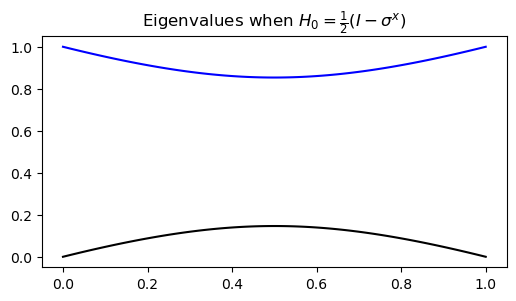

In [7]:
tt = np.linspace(0., 1., 100)
ffp = fp_ok(tt)
ffm = fm_ok(tt)
plt.figure(figsize=(6,3))
plt.plot(tt, ffp, 'b')
plt.plot(tt, ffm, 'k')
plt.title(r"Eigenvalues when $H_0 = \frac{1}{2}(I-\sigma^x)$")
#plt.savefig("OneBitDisagreeFine.eps")
plt.show()

## Commuting Hamiltonians

We now consider the case where the initial and the final Hamiltonians $\mathcal{H}_0$ and $\mathcal{H}_F$ do commute, namely
$$
[\mathcal{H}_0, \mathcal{H}_F] := \mathcal{H}_0\mathcal{H}_F - \mathcal{H}_F \mathcal{H}_0 = 0.
$$

Consider now
$$
\Hh_0 := \frac{1-\sigma^z}{2}
 = \frac{1}{2}\begin{pmatrix}
 0 & 0 \\
 0 & 1
 \end{pmatrix}
  = \ket{1}\bra{1}.
$$
One can check that
\begin{align}
\Hh_0\ket{0} & = \ket{1}\bra{1}\ket{0} = 0,\qquad\text{(ground state)}\\
\Hh_0\ket{1} & = \ket{1}\bra{1}\ket{1} = \ket{1}.
\end{align}
Interpolating Hamiltonian:
$$
\Hh(t) := \left(1-t\right)\Hh_0 + t\Hh_F
 = \begin{pmatrix}
t & 0\\
0 & 1-t
 \end{pmatrix}, \qquad\text{for }t\in [0,1].
$$
Eigenvalues:
$\lambda(t) \in \{t, 1-t\}$:
$\Hh(t)\ket{0} = t\ket{0}$
and 
$\Hh(t)\ket{1} = (1-t)\ket{1}$.


In [4]:
def fp_problem(t):
    return t

def fm_problem(t):
    return 1-t

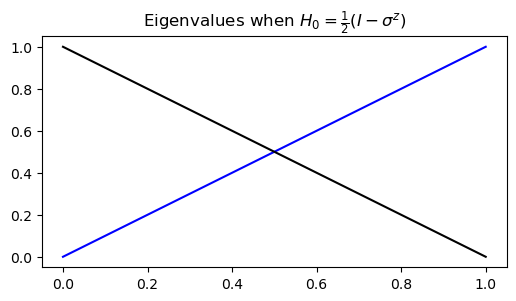

In [8]:
tt = np.linspace(0., 1., 100)
ffp = fp_problem(tt)
ffm = fm_problem(tt)
plt.figure(figsize=(6,3))
plt.plot(tt, ffp, 'b')
plt.plot(tt, ffm, 'k')
plt.title(r"Eigenvalues when $H_0 = \frac{1}{2}(I-\sigma^z)$")
#plt.savefig("OneBitDisagreePb.eps")
plt.show()

## Possible fix: adding noise

Consider a noisy version of the interpolating Hamiltonian:
$$
\Hh^{\varepsilon}(t) := \Hh(t) + \varepsilon
\begin{pmatrix}
0 & t(1-t)\\
t(1-t) & 0
 \end{pmatrix}
 = \begin{pmatrix}
t & \varepsilon t(1-t)\\
\varepsilon t(1-t) & 1-t
 \end{pmatrix}, \qquad\text{for }t\in [0,1].
$$

In [9]:
def fp_problem_eps(t, eps):
    return .5 + np.sqrt(4*eps**2*t**4 - 8*eps**2*t**3 + 4*eps**2*t**2 + 4*t**2 - 4*t + 1)/2.

def fm_problem_eps(t, eps):
    return .5 - np.sqrt(4*eps**2*t**4 - 8*eps**2*t**3 + 4*eps**2*t**2 + 4*t**2 - 4*t + 1)/2.

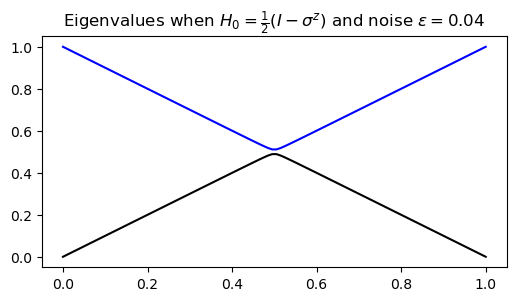

In [13]:
eps = 0.04
tt = np.linspace(0., 1., 100)
ffp = fp_problem_eps(tt, eps)
ffm = fm_problem_eps(tt, eps)
plt.figure(figsize=(6,3))
plt.plot(tt, ffp, 'b')
plt.plot(tt, ffm, 'k')
plt.title(r"Eigenvalues when $H_0 = \frac{1}{2}(I-\sigma^z)$ and noise $\epsilon=$%.2f"  %eps)
#plt.savefig("OneBitDisagreePbNoise.eps")
plt.show()

# The 2-bit Disagree problem

The 2-bit Disagree problem reads
\begin{equation*}
f(x) := \left\{
\begin{array}{ll}
0, & \text{if } x_1 \ne x_2,\\
1, & \text{otherwise}.
\end{array}
\right.
\end{equation*}
$$
\Hh_F := \begin{pmatrix}
1 & 0  & 0 & 0\\
0 & 0  & 0 & 0\\
0 & 0  & 0 & 0\\
0 & 0  & 0 & 1
\end{pmatrix}
 = \frac{1}{2}\left\{\Ig\otimes\Ig + (\Zg\otimes\Ig)(\Ig\otimes\Zg)\right\}
 = \frac{1+\sigma_1^z\sigma_2^z}{2},
$$
with $\Ig$ the identity matrix in $\Mm_2(\RR)$,
$\Zg = \begin{pmatrix}
1 & 0 \\ 0 & -1
\end{pmatrix}$
and $\otimes$ the Kronecker product.
Eigenvalues:
$$
e_{1}^F = \begin{pmatrix} 0\\1\\0\\1\end{pmatrix},\qquad
e_{2}^F = \begin{pmatrix} 0\\0\\1\\0\end{pmatrix},\qquad
e_{3}^F = \begin{pmatrix} 1\\0\\0\\0\end{pmatrix},\qquad
e_{4}^F = \begin{pmatrix} 0\\0\\0\\1\end{pmatrix},
$$
with eigenvalues $0,0,1,1$, so that the ground states are $\{e_1^F,e_2^F\}$.

- Initial Hamiltonian:
\begin{align*}
\Hh_0 = \frac{1}{2}\sum_{i=1}^{2}(1-\sigma_i^x)
 & = \frac{1}{2}\left\{(\Ig\otimes\Ig - \Xg\otimes\Ig) + (\Ig\otimes\Ig - \Ig\otimes\Xg)\right\}\\
 & = 
\frac{1}{2}\begin{pmatrix}
2 & -1 & -1 & 0\\
-1 & 2 & 0 & -1\\
-1 & 0 & 2 & -1\\
0 & -1 & -1 & 2
\end{pmatrix};
\end{align*}
- Eigenvalues $\{0, 1, 1, 2\}$ and ground state
$e_1^0 = (1,1,1,1)^{\top}=2\ket{++}$;
- Take
$\Hh_t := (1-r(t)) \Hh_0 + r(t) \Hh_F$;
- Apply the Quantum Adiabatic theorem.

**Questions**
- How to find $\Hh_0$ in general? Idea: PQC.
- Reality has noise: $\Hh_t \longrightarrow \Hh_t^\varepsilon$ for all $t\in (0,1)$ (or noise-induced algorithm);
- Question: understand $\Hh^\varepsilon$ as $\varepsilon\downarrow 0$.

## Initialisation of the system: initial and terminal Hamiltonians

In [14]:
I = sym.Matrix([[1, 0],  [0, 1]])
X = sym.Matrix([[0, 1],  [1, 0]])
Z = sym.Matrix([[1, 0],  [0, -1]])

HF = (TensorProduct(I,I) + TensorProduct(Z, I)*TensorProduct(I, Z)) / 2

H0 = ((TensorProduct(I, I) - TensorProduct(X,I)) + (TensorProduct(I, I) - TensorProduct(I,X))) / 2
sym.pprint("Initial Hamiltonian (H0)= ")
sym.pprint(H0)
sym.pprint("  ")

sym.pprint("Final Hamiltonian (HF): ")
sym.pprint(HF)


sym.pprint("  ")
print("Eigenvalues, eigenvectors of H0 (with their algebraic multiplicity): ")
ev = H0.eigenvects()
sym.pprint(ev)


sym.pprint("  ")
print("Eigenvalues, eigenvectors of HF (with their algebraic multiplicity): ")
ev = HF.eigenvects()
sym.pprint(ev)

Initial Hamiltonian (H0)= 
⎡ 1    -1/2  -1/2   0  ⎤
⎢                      ⎥
⎢-1/2   1     0    -1/2⎥
⎢                      ⎥
⎢-1/2   0     1    -1/2⎥
⎢                      ⎥
⎣ 0    -1/2  -1/2   1  ⎦
  
Final Hamiltonian (HF): 
⎡1  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  1⎦
  
Eigenvalues, eigenvectors of H0 (with their algebraic multiplicity): 
⎡⎛      ⎡⎡1⎤⎤⎞  ⎛      ⎡⎡0 ⎤  ⎡-1⎤⎤⎞  ⎛      ⎡⎡1 ⎤⎤⎞⎤
⎢⎜      ⎢⎢ ⎥⎥⎟  ⎜      ⎢⎢  ⎥  ⎢  ⎥⎥⎟  ⎜      ⎢⎢  ⎥⎥⎟⎥
⎢⎜      ⎢⎢1⎥⎥⎟  ⎜      ⎢⎢-1⎥  ⎢0 ⎥⎥⎟  ⎜      ⎢⎢-1⎥⎥⎟⎥
⎢⎜0, 1, ⎢⎢ ⎥⎥⎟, ⎜1, 2, ⎢⎢  ⎥, ⎢  ⎥⎥⎟, ⎜2, 1, ⎢⎢  ⎥⎥⎟⎥
⎢⎜      ⎢⎢1⎥⎥⎟  ⎜      ⎢⎢1 ⎥  ⎢0 ⎥⎥⎟  ⎜      ⎢⎢-1⎥⎥⎟⎥
⎢⎜      ⎢⎢ ⎥⎥⎟  ⎜      ⎢⎢  ⎥  ⎢  ⎥⎥⎟  ⎜      ⎢⎢  ⎥⎥⎟⎥
⎣⎝      ⎣⎣1⎦⎦⎠  ⎝      ⎣⎣0 ⎦  ⎣1 ⎦⎦⎠  ⎝      ⎣⎣1 ⎦⎦⎠⎦
  
Eigenvalues, eigenvectors of HF (with their algebraic multiplicity): 
⎡⎛      ⎡⎡0⎤  ⎡0⎤⎤⎞  ⎛      ⎡⎡1⎤  ⎡0⎤⎤⎞⎤
⎢⎜      ⎢⎢ ⎥  ⎢ ⎥⎥⎟  ⎜      ⎢⎢ ⎥  ⎢ ⎥⎥⎟⎥
⎢⎜      ⎢⎢1⎥  ⎢0⎥⎥⎟  ⎜      ⎢⎢0⎥  ⎢0⎥⎥⎟⎥
⎢⎜0, 2, ⎢⎢ ⎥, ⎢ ⎥⎥⎟, ⎜1, 2, ⎢⎢ ⎥

### Computing the Lie bracket

In [15]:
H0*HF - HF*H0

Matrix([
[   0, 1/2, 1/2,    0],
[-1/2,   0,   0, -1/2],
[-1/2,   0,   0, -1/2],
[   0, 1/2, 1/2,    0]])

## Time-dependent Hamiltonian

In [16]:
t = symbols('t', real=True)

## Time-dependent Hamiltonian
def H(t):
    return (1-t)*H0 + t*HF

In [17]:
sym.pprint(H(t))

⎡       t   1  t   1       ⎤
⎢  1    ─ - ─  ─ - ─    0  ⎥
⎢       2   2  2   2       ⎥
⎢                          ⎥
⎢t   1                t   1⎥
⎢─ - ─  1 - t    0    ─ - ─⎥
⎢2   2                2   2⎥
⎢                          ⎥
⎢t   1                t   1⎥
⎢─ - ─    0    1 - t  ─ - ─⎥
⎢2   2                2   2⎥
⎢                          ⎥
⎢       t   1  t   1       ⎥
⎢  0    ─ - ─  ─ - ─    1  ⎥
⎣       2   2  2   2       ⎦


## Eigenvalues of H(t)

In [18]:
def eigenValues(tt):
    ev = [H(t).eigenvects() for t in tt]
    eigenval0, eigenval1, eigenval2, eigenval3 = [], [], [], []
        
    for e in ev:
        try:
            temp = e[0][0]
            eigenval0.append(temp)
        except:
            eigenval0.append(0.)
        try:
            temp = e[1][0]
            eigenval1.append(temp)
        except:
            eigenval1.append(0.)
        try:
            temp = e[2][0]
            eigenval2.append(temp)
        except:
            eigenval2.append(0.)
        try:
            temp = e[3][0]
            eigenval3.append(temp)
        except:
            eigenval3.append(0.)
            
    return eigenval0, eigenval1, eigenval2, eigenval3

## Plotting function

In [19]:
def runPlot(realtime, eigenvalsH):
    eigenval0, eigenval1, eigenval2, eigenval3 = eigenvalsH
    
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    plt.plot(realtime, eigenval0, label=r'$\lambda_0$')
    plt.plot(realtime, eigenval1, label=r'$\lambda_1$')
    plt.plot(realtime, eigenval2, label=r'$\lambda_2$')
    plt.plot(realtime, eigenval3, label=r'$\lambda_3$')
    plt.legend(loc="best")
    plt.title("Eigenvalues")

    tt = [adiabaticPath(t) for t in realtime]
    plt.subplot(1, 2, 2)
    plt.plot(realtime, tt, 'b')
    plt.title("Time-interpolation function")
    plt.tight_layout()
    plt.show()

## Numerical examples

In [20]:
eps = 1E-5
realtime = np.linspace(eps, 1.-eps , 100)

### Example 1

In [21]:
def adiabaticPath(realtime): 
    return realtime

Eigenvalues:  2  | Multiplicity:  1
Eigenvalues:  1  | Multiplicity:  2
Eigenvalues:  0  | Multiplicity:  1


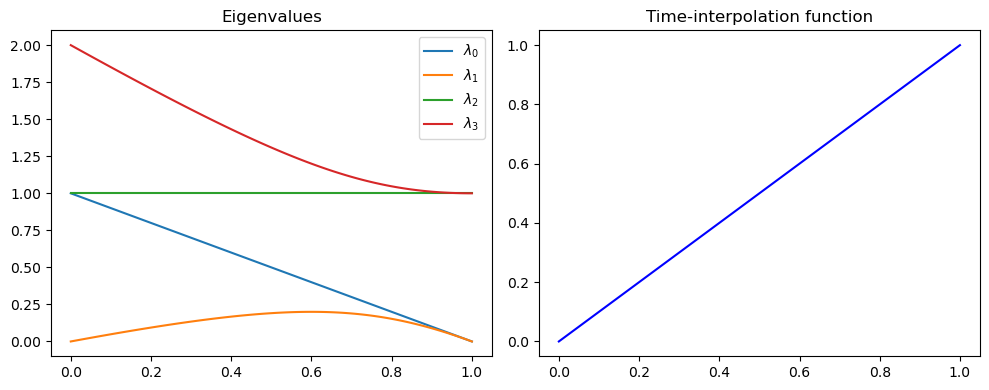

In [22]:
tt = adiabaticPath(realtime)

eigenH0 = H(0).eigenvals(0)

for e in eigenH0.keys():
    print("Eigenvalues: ", e, " | Multiplicity: ",  eigenH0[e])
    
eigenvalsH = eigenValues(tt)
runPlot(realtime, eigenvalsH)

### Example 2

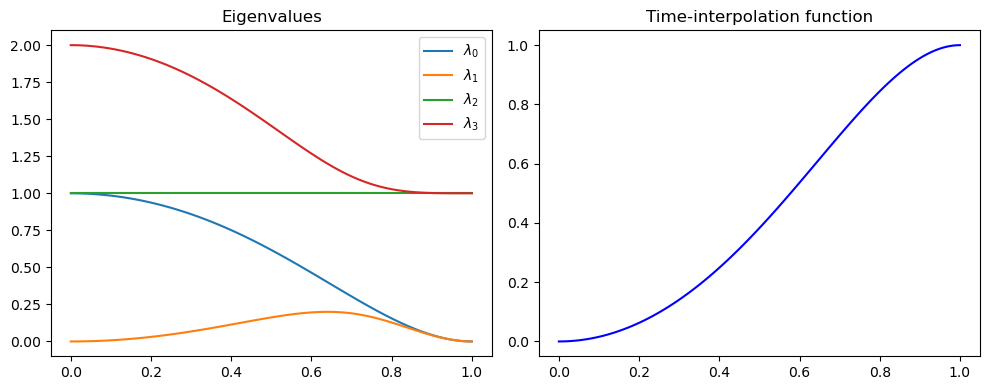

In [23]:
def adiabaticPath(realtime):
    return sym.sin(realtime**2*sym.pi/2.)

tt = [adiabaticPath(t) for t in realtime]
eigenvalsH = eigenValues(tt)
runPlot(realtime, eigenvalsH)

# Warning: a note on commuting Hamiltonians

In [24]:
H0 = sym.Matrix([[1, 0],  [0, -1]])
HF = sym.Matrix([[-2, 0],  [0, -1]])

def H(t, T):
    return (1-t/T)*H0 + (t/T)*HF

sym.pprint(H0)
sym.pprint(HF)

⎡1  0 ⎤
⎢     ⎥
⎣0  -1⎦
⎡-2  0 ⎤
⎢      ⎥
⎣0   -1⎦


#### Compute the Lie bracket

Lie bracket $[H_0, H_F] := H_0 H_F - H_F H_0$


In [25]:
sym.pprint(H0*HF - HF*H0)

⎡0  0⎤
⎢    ⎥
⎣0  0⎦


In [26]:
print("Eigenvalues, eigenvectors of H0: ")
ev = H0.eigenvects()
sym.pprint(ev)

print("  ")
print("Eigenvalues, eigenvectors of HF: ")
ev = HF.eigenvects()
sym.pprint(ev)

Eigenvalues, eigenvectors of H0: 
⎡⎛       ⎡⎡0⎤⎤⎞  ⎛      ⎡⎡1⎤⎤⎞⎤
⎢⎜-1, 1, ⎢⎢ ⎥⎥⎟, ⎜1, 1, ⎢⎢ ⎥⎥⎟⎥
⎣⎝       ⎣⎣1⎦⎦⎠  ⎝      ⎣⎣0⎦⎦⎠⎦
  
Eigenvalues, eigenvectors of HF: 
⎡⎛       ⎡⎡1⎤⎤⎞  ⎛       ⎡⎡0⎤⎤⎞⎤
⎢⎜-2, 1, ⎢⎢ ⎥⎥⎟, ⎜-1, 1, ⎢⎢ ⎥⎥⎟⎥
⎣⎝       ⎣⎣0⎦⎦⎠  ⎝       ⎣⎣1⎦⎦⎠⎦


The minimum runtime is given by 
$$
T \geq \max_{t}\frac{\|H_T - H_0\|^2}{\varepsilon S_{gap}(t)^3},
$$
where $S_{gap}$ denotes the spectral gap, and $\varepsilon$ is a tolerance level such that
$$
\sqrt{\langle \psi_0|\psi_{F} \rangle} \leq \varepsilon.
$$

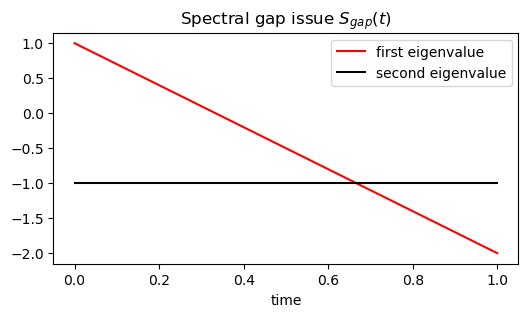

In [28]:
T = 1.
tt = np.linspace(0., T, 20)
spectralgap, eigvals0, eigvals1 = [], [], []

for t in tt:
    Ht = H(t, T)
    ev = Ht.eigenvals() ## returns the eigenvalues with their algebraic multiplicities
    listeigenvals = list(ev.keys())
    eigvals0.append(listeigenvals[0])
    eigvals1.append(listeigenvals[1])

plt.figure(figsize=(6,3))
plt.plot(tt, eigvals0, 'r', label="first eigenvalue")
plt.plot(tt, eigvals1, 'k', label="second eigenvalue")
plt.title("Spectral gap issue $S_{gap}(t)$")
plt.legend(loc="best")
plt.xlabel("time")
plt.show()